# investment plots

2021-07-11

See: <https://github.com/matplotlib/mplfinance>

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import mplfinance as mpf
import pandas_ta as pta

## Helper functions

In [2]:
def calc_date_str(x):
    year = np.floor(x['<DATE>'] / 10000)
    month = np.floor((x['<DATE>'] % 10000) / 100)
    day = np.floor((x['<DATE>'] % 100))
    hours = np.floor(x['<TIME>'] / 10000) - 6.0
    minutes = np.floor((x['<TIME>'] % 10000) / 100)
    seconds = np.floor((x['<TIME>'] % 100))
    s = '%i-%02i-%02i %02i:%02i:%02i' % (year, month, day, hours, minutes, seconds)
    return s

In [3]:
def clean_stooq_df(df):
    _df = df.drop(['<TICKER>', '<PER>', '<OPENINT>'], axis=1)
    _df['Date'] = _df.apply(calc_date_str, axis=1)
    _df['Date'] = pd.to_datetime(_df['Date'])
    _df = _df.drop(['<DATE>', '<TIME>'], axis=1)
    _df = _df.rename(columns={'<OPEN>': 'Open', '<HIGH>': 'High', '<LOW>': 'Low', '<CLOSE>': 'Close', '<VOL>': 'Volume' })
    _df = _df.reindex(columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume'])
    _df.index = _df['Date']
    _df = _df.drop('Date', axis=1)
    _df['Volume'] = _df['Volume']/1000.
    return _df

In [4]:
def calc_metrics(df, metrics):
    addplots = list()
    if metrics is None:
        metrics = list()
    h0 = None
    if 'rsi' in metrics:
        rsi_period = 14
        rsi = pta.rsi(df['Close'], length=rsi_period)
        rsi = rsi - 50.
        fast = 5
        slow = 20
        signal = 5
        h0 = pd.Series([0.]*len(rsi.index), rsi.index)
        addplots.extend([
            mpf.make_addplot(h0, panel=2, type='line', ylabel='RSI', color='gray', linestyle='dashed', width=1, ylim=(-60, 60)),
            mpf.make_addplot(rsi, panel=2, type='line', color='darkorange', secondary_y=False, width=2),
        ])
    if 'smi' in metrics:
        smi = pta.smi(df['Close'], fast=fast, slow=slow, signal=signal)
        smi_key = 'SMIo_%i_%i_%i' % (fast, slow, signal)
        smi_osc = smi[smi_key]*100.
        if h0 is None:
            h0 = pd.Series([0.]*len(smi.index), smi.index)
        addplots.extend([
            mpf.make_addplot(h0, panel=3, type='line', ylabel='SMI', color='gray', linestyle='dashed', width=1, ylim=(-60, 60)),
        mpf.make_addplot(smi_osc, panel=3, type='line', secondary_y=False, width=2),
        ])
    if 'macd' in metrics:
        fast_macd = 5
        slow_macd = 20
        signal_macd = 5
        macd = pta.macd(df['Close'], fast=fast_macd, slow=slow_macd, signal=signal_macd)
        macd_key = 'MACD_%i_%i_%i' % (fast_macd, slow_macd, signal_macd)
        macd_osc = macd[macd_key]
        if h0 is None:
            h0 = pd.Series([0.]*len(macd_osc.index), macd_osc.index)
        addplots.extend([
            mpf.make_addplot(h0, panel=4, type='line',  ylabel='MACD', color='gray', linestyle='dashed', width=1),
            mpf.make_addplot(macd_osc, panel=4, type='line', color='green', secondary_y=False, width=2),
        ])
    return addplots

In [5]:
def plot_candles(df, metrics=None, mav=None):
    if metrics is None:
        metrics = list()
    if mav is None:
        mav = list()
    addplots = calc_metrics(df, metrics)
    n_metrics = len(metrics)
    panel_ratios = [2, 0.6] + [1]*n_metrics
    figscale = 1.4
    mpf.plot(df, type='candle', volume=True, style='charles', addplot=addplots, mav=mav, panel_ratios=panel_ratios, figscale=figscale)

## Read data from Stooq

https://stooq.com/db/h/

In [6]:
arkw = pd.read_csv('../stooq/daily/us/nyse_etfs/1/arkw.us.txt', skipinitialspace=True)

In [7]:
arkw.head()

,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>,<OPENINT>
0,ARKW.US,D,20141008,0,16.562,16.867,16.436,16.867,4989,0
1,ARKW.US,D,20141009,0,16.859,16.893,16.580,16.631,19398,0
2,ARKW.US,D,20141010,0,16.292,16.580,16.038,16.038,3940,0
3,ARKW.US,D,20141013,0,15.987,16.055,15.835,16.055,4739,0
4,ARKW.US,D,20141014,0,15.928,15.928,15.818,15.877,6118,0


In [8]:
df = clean_stooq_df(arkw)

In [9]:
df.tail(20)

,Open,High,Low,Close,Volume
Date,,,,,
2021-06-11 06:00:00,139.4900,140.6000,139.0800,140.46,412.349
2021-06-14 06:00:00,141.2100,143.5500,141.2100,142.65,973.825
2021-06-15 06:00:00,142.3400,142.9600,139.3101,139.61,618.638
2021-06-16 06:00:00,139.5700,140.6700,136.9210,139.56,846.231
2021-06-17 06:00:00,138.8164,144.2994,138.6100,143.41,852.469
2021-06-18 06:00:00,142.8400,145.1800,142.7100,143.93,930.660
2021-06-21 06:00:00,143.2800,144.2800,140.6502,143.54,876.573
2021-06-22 06:00:00,142.6900,146.2500,142.5400,145.99,1296.608
2021-06-23 06:00:00,147.0399,149.3500,146.9200,148.79,1146.553


In [10]:
#dft = df.head(80)
dft = df.tail(120)

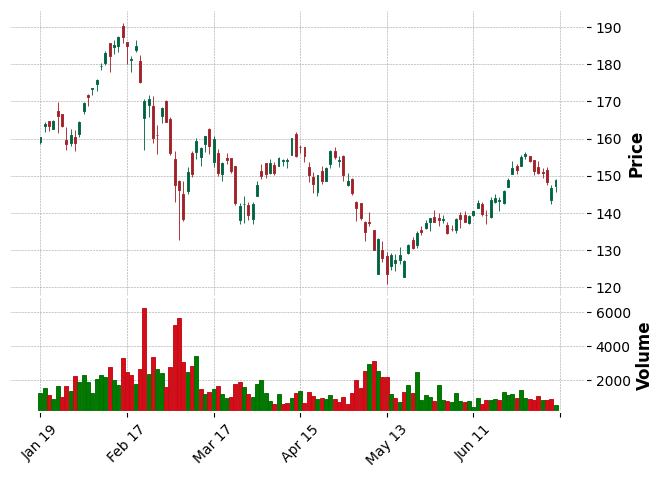

In [11]:
mpf.plot(dft, type='candle', volume=True, style='charles')

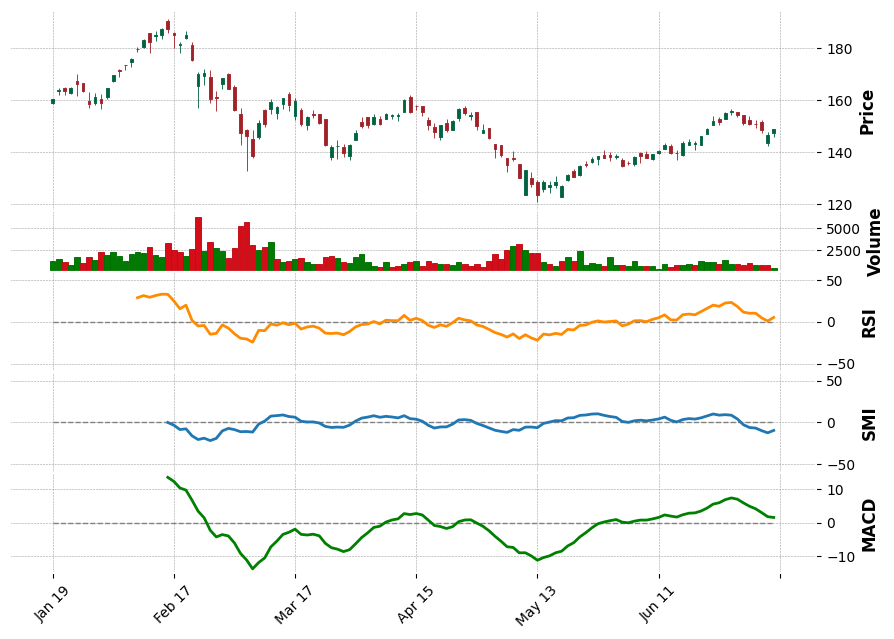

In [12]:
metrics = ['rsi', 'smi', 'macd']
plot_candles(dft, metrics=metrics)

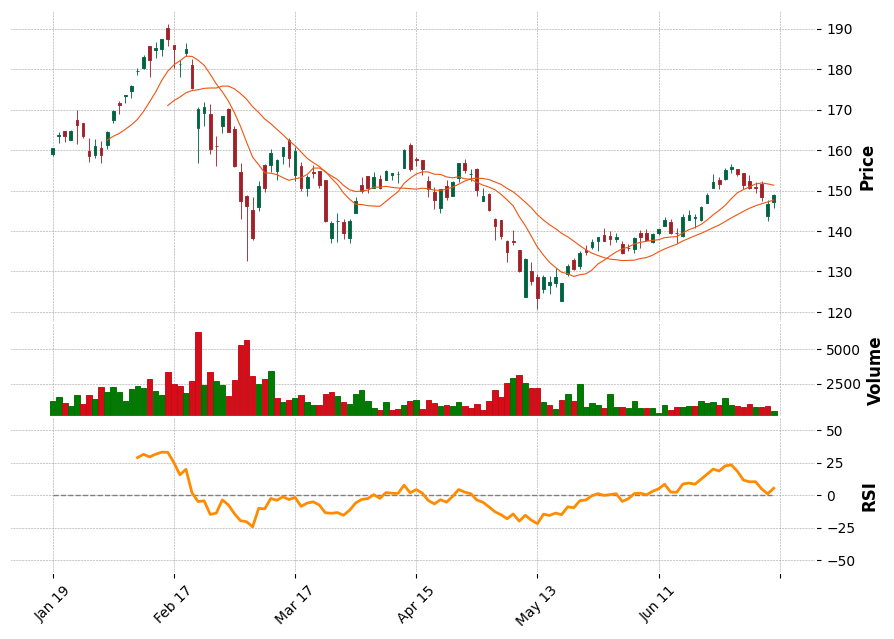

In [14]:
metrics = ['rsi']
plot_candles(dft, metrics=metrics, mav=(10, 20))